In [1]:
from typing import Optional
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.nn import ReLU

from pfhedge.instruments import BrownianStock
from pfhedge.instruments import EuropeanOption
from pfhedge.instruments import FixedStock
from pfhedge.nn import BlackScholes
from pfhedge.nn import BSEuropeanOption
from pfhedge.nn import EntropicRiskMeasure
from pfhedge.nn import ExpectedShortfall
from pfhedge.nn import Hedger
from pfhedge.nn import MultiLayerPerceptron

### Utility

In [2]:
def load_quotes(file_path: str) -> torch.Tensor:
    quotes = pd.read_csv(file_path)
    close = torch.tensor(quotes["Close"].values, dtype=torch.float)
    return close


def generate_log_normal_brownian(
    sigma: float, mu: float, dt: float, n_steps: int, seed: Optional[int] = None
) -> Tuple[torch.Tensor, torch.Tensor]:
    """Generate a log-normal Brownian motion time series.

    Args:
        sigma (float): Volatility parameter.
        dt (float): Time step size.
        n_steps (int): Number of time steps.
        seed (int, optional): Random seed for reproducibility.

    Returns:
        Tuple[torch.Tensor, torch.Tensor]: Tuple containing the log series and the
            exponential series.
    """
    if seed is not None:
        torch.manual_seed(seed)
    # Generate Brownian increments
    increments = torch.randn(n_steps - 1) * np.sqrt(sigma**2 * dt) + mu * dt
    # Convert to log-normal Brownian motion
    log_series = torch.cat([torch.zeros(1), torch.cumsum(increments, dim=0)])
    series = torch.exp(log_series)
    return series


def get_derivative(
    sigma: float, mu: float, dt: float, strike: float, maturity: float, cost: float = 0.0
) -> EuropeanOption:
    stock = BrownianStock(cost=cost, sigma=sigma, mu=mu, dt=dt)
    derivative = EuropeanOption(stock, strike=strike, maturity=maturity)
    return derivative


def loss_hedger(loss, derivative, features, n_epochs, n_paths, init_spot) -> Hedger:
    # Create MLP hedger
    model = MultiLayerPerceptron(n_layers=4, n_units=[64, 32, 32, 16], activation=ReLU())
    hedger = Hedger(model, features, criterion=loss)
    # Fit the hedger
    hedger.fit(derivative, n_epochs=n_epochs, n_paths=n_paths, init_state=(init_spot,))
    return hedger


def blackscholes_hedger(derivative) -> Hedger:
    # Create instruments
    model = BlackScholes(derivative)
    hedger_bs = Hedger(model, model.inputs())
    return hedger_bs

### Instruments

In [24]:
torch.manual_seed(1234)

# Set up the instruments
dt = 1 / 250
vol = 0.4
mu = 0.0
init_spot = 3
cost = 0.001

# Set up the derivative
strike = 3
term = 30
maturity = term * dt
features = ["log_moneyness", "expiry_time", "volatility", "prev_hedge"]

# series = generate_log_normal_brownian(sigma=vol, mu=mu, dt=dt, n_steps=term * 3 + 10)
series = load_quotes("000905.csv")
fixed_stock = FixedStock(spots=list(series), cost=cost, dt=dt)
sigma = fixed_stock.volatility  # use realized volatility in simulation
print(f"Realized Volatility: {sigma:.6f}")

Realized Volatility: 0.210123


### Hedgers

In [25]:
# Set trainging parameters
n_epochs = 200
n_paths = 10000

# Set up the hedgers
loss_functions = {
    "Entropic Risk Measure (a=1)": EntropicRiskMeasure(a=1),
    "Entropic Risk Measure (a=0.1)": EntropicRiskMeasure(a=0.1),
    "Expected Shortfall (95%)": ExpectedShortfall(0.05),
    "Expected Shortfall (50%)": ExpectedShortfall(0.5),
}
hedgers = {}
derivative = get_derivative(sigma, mu=mu, dt=dt, cost=cost, strike=strike, maturity=maturity)
hedger = blackscholes_hedger(derivative)
hedgers["Black-Scholes"] = (hedger, derivative)
for name, loss in loss_functions.items():
    derivative = get_derivative(sigma, mu=mu, dt=dt, cost=cost, strike=strike, maturity=maturity)
    hedger = loss_hedger(loss, derivative, features, n_epochs, n_paths, init_spot)
    hedgers[name] = (hedger, derivative)

Loss=0.1152: 100%|██████████| 200/200 [00:15<00:00, 13.08it/s]


### PnL Distribution

PnL Statistics:
Black-Scholes: -0.093414 (0.014219)
Entropic Risk Measure (a=1): -0.088247 (0.067519)
Entropic Risk Measure (a=0.1): -0.085532 (0.131025)
Expected Shortfall (95%): -0.092344 (0.024772)
Expected Shortfall (50%): -0.090152 (0.032287)


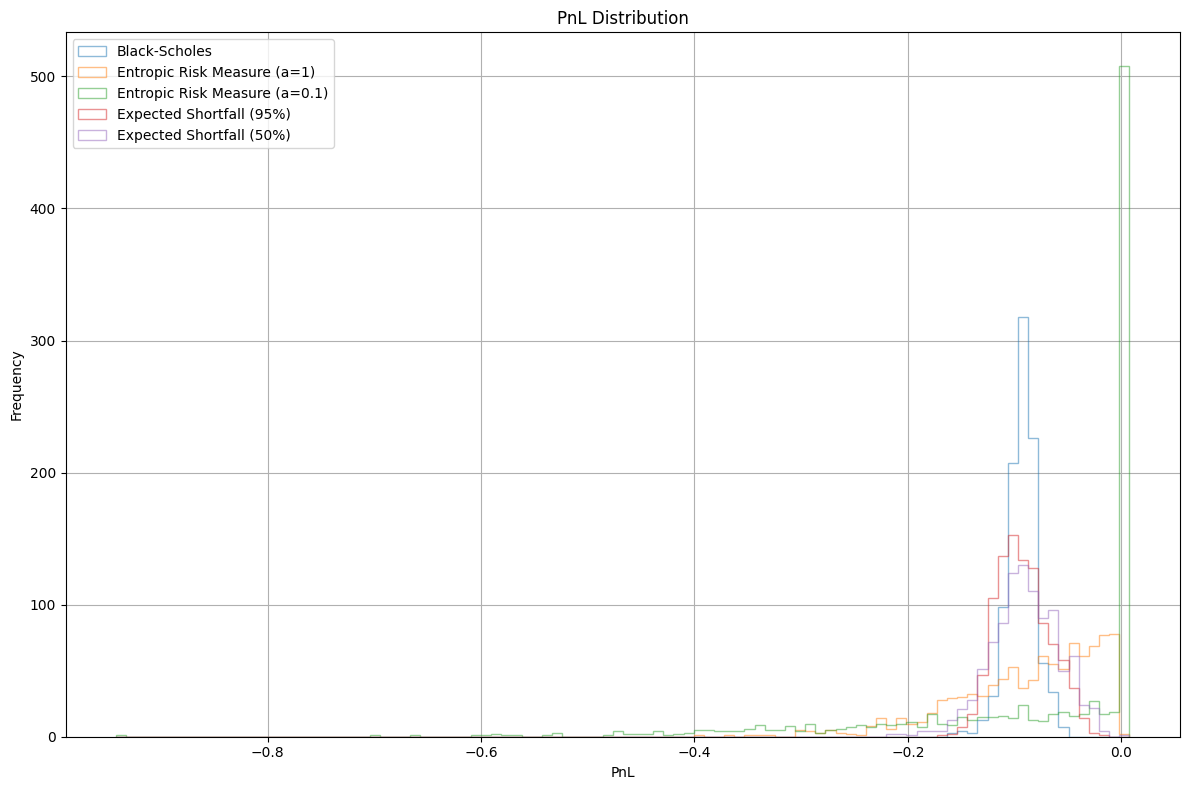

In [26]:
# PnL statistics
pnls = {}
for name, (hedger, derivative) in hedgers.items():
    derivative.simulate(n_paths=1000, init_state=(init_spot,))
    pnls[name] = hedger.compute_pl(derivative)
print("PnL Statistics:")
for name, pnl in pnls.items():
    print(f"{name}: {pnl.mean():.6f} ({pnl.std():.6f})")

# Calculate global min and max for uniform binning
all_pnls = torch.cat([pnl for pnl in pnls.values()]).detach().numpy()
bin_edges = np.linspace(all_pnls.min(), all_pnls.max(), 101)
# Plot PnL distributions
plt.figure(figsize=(12, 8))
for name, pnl in pnls.items():
    plt.hist(pnl.detach().numpy(), bins=bin_edges, label=name, histtype="step", alpha=0.5)
plt.title("PnL Distribution")
plt.xlabel("PnL")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Backtest

Black-Scholes: -0.080430 (0.024508)
Entropic Risk Measure (a=1): -0.080847 (0.085078)
Entropic Risk Measure (a=0.1): -0.087069 (0.169627)
Expected Shortfall (95%): -0.080507 (0.038907)
Expected Shortfall (50%): -0.079686 (0.048030)


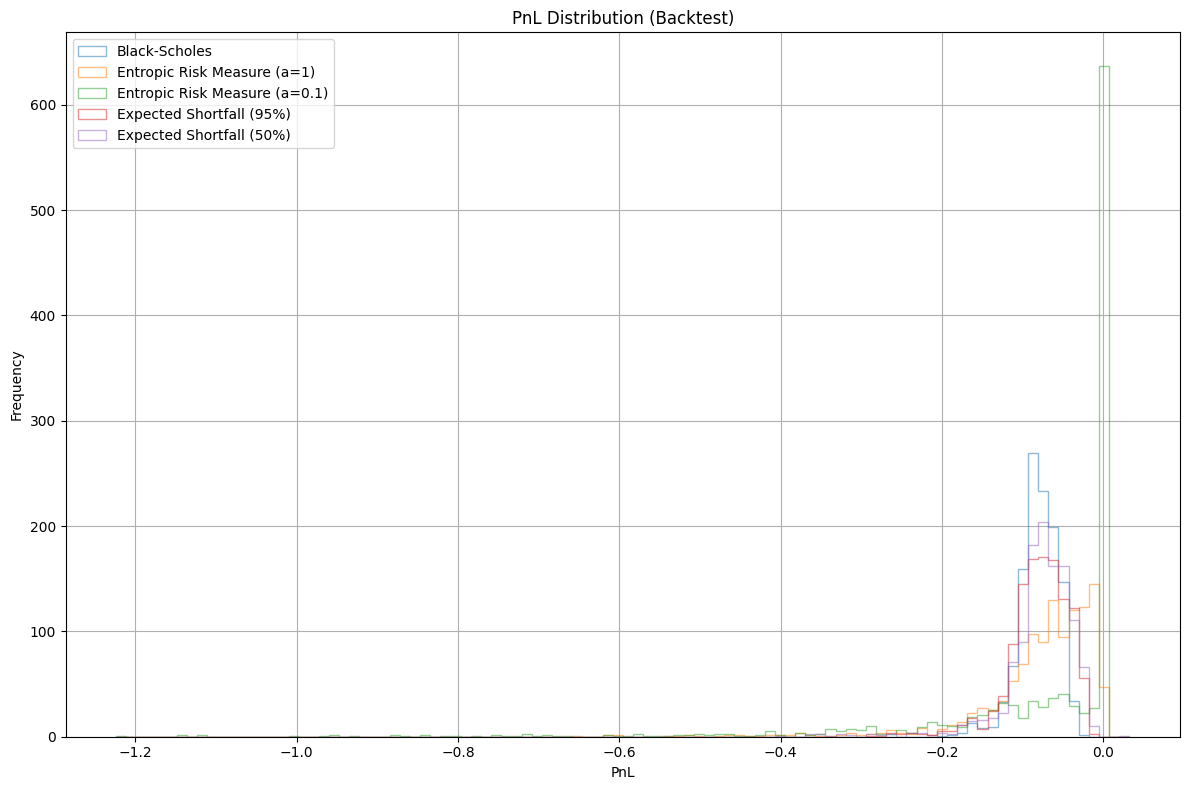

In [27]:
# Backtest on the fixed stock
fixed_derivative = EuropeanOption(fixed_stock, strike=strike, maturity=maturity)
fixed_derivative.simulate(n_paths=fixed_stock.max_n_paths(maturity), init_state=(init_spot,))
backtest_pnls = {}
for name, (hedger, _) in hedgers.items():
    pnl = hedger.compute_pl(fixed_derivative)
    backtest_pnls[name] = pnl
    print(f"{name}: {pnl.mean():.6f} ({pnl.std():.6f})")

# calculate min and max for uniform binning
all_pnls = torch.cat([pnl for pnl in backtest_pnls.values()]).detach().numpy()
bin_edges = np.linspace(all_pnls.min(), all_pnls.max(), 101)
# plot backtest pnl
plt.figure(figsize=(12, 8))
for name, pnl in backtest_pnls.items():
    plt.hist(pnl.detach().numpy(), bins=bin_edges, label=name, histtype="step", alpha=0.5)
plt.title("PnL Distribution (Backtest)")
plt.xlabel("PnL")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

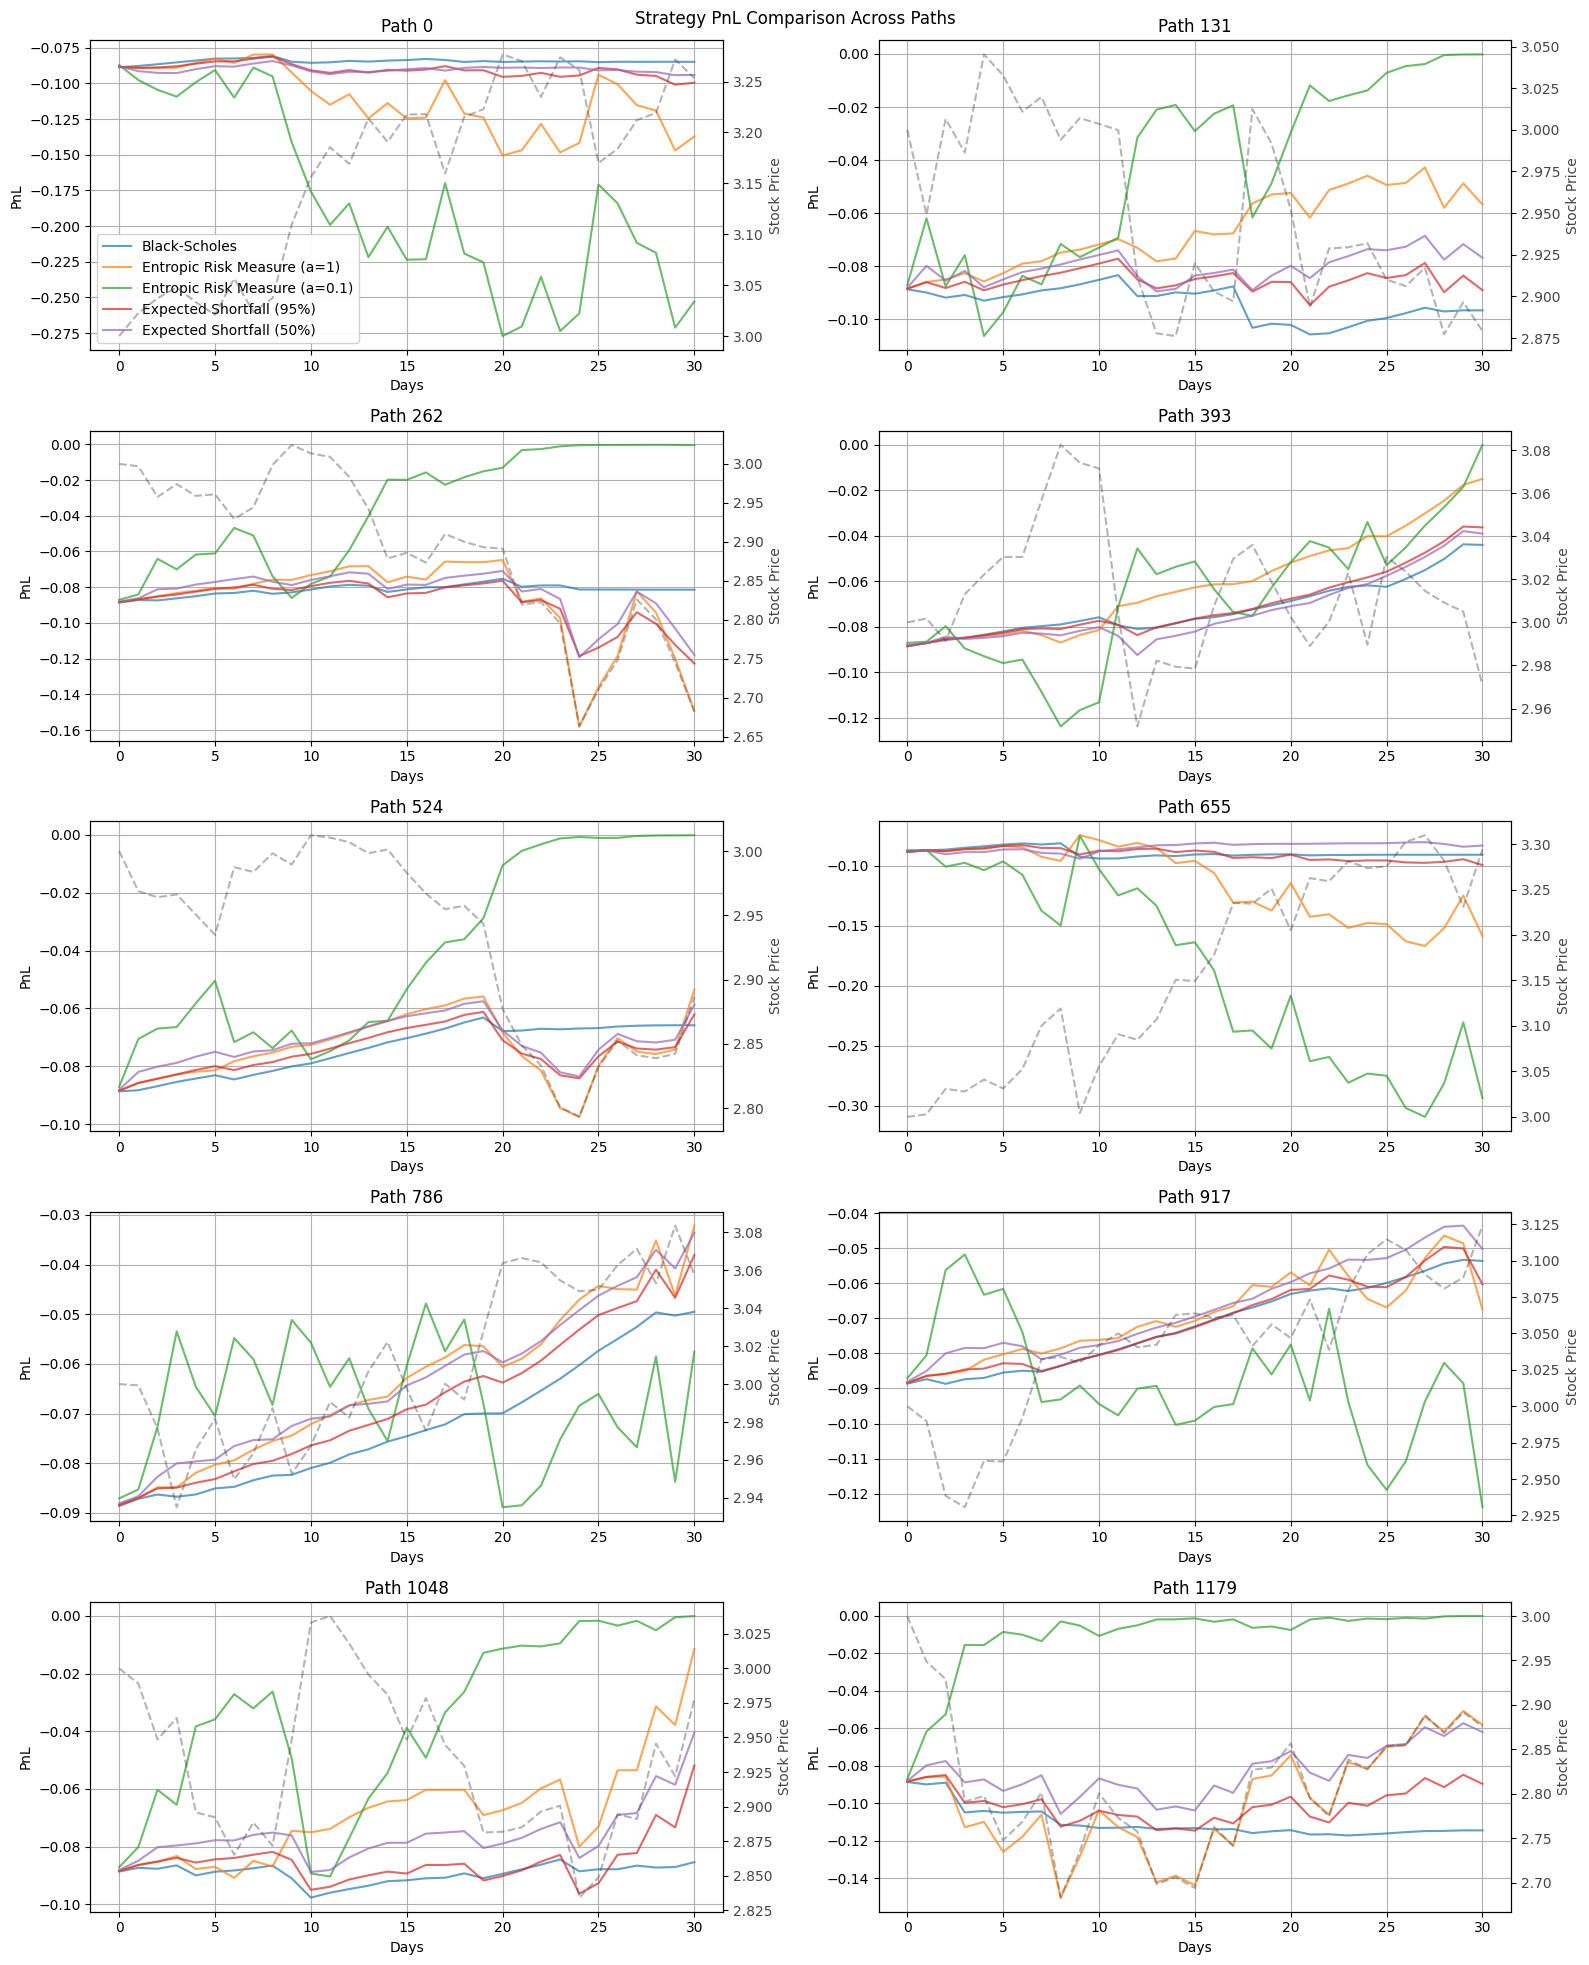

In [28]:
# daily PnL
bs_priceable = BSEuropeanOption.from_derivative(fixed_derivative)
daily_pnls = {}
# select paths
daily_pnl_num = 10
pnl_days = torch.linspace(0, fixed_stock.max_n_paths(maturity) - 1, daily_pnl_num).long()
for name, (hedger, _) in hedgers.items():
    daily_pnls[name] = hedger.compute_cum_pl(fixed_derivative, priceable=bs_priceable)[pnl_days]

# Get corresponding stock paths
stock_paths = fixed_stock.spot[pnl_days]

# Create subplot grid based on path count
n_cols = 2
n_rows = (daily_pnl_num + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
colors = plt.cm.tab10.colors
# Plot each path across all strategies
for path_idx, ax in enumerate(axes.flat):
    if path_idx >= daily_pnl_num:
        ax.set_visible(False)
        continue

    # Plot strategies' PnL
    for i, (name, pnl) in enumerate(daily_pnls.items()):
        pnl_path = pnl[path_idx].detach().numpy()
        color = colors[i % len(colors)]
        ax.plot(pnl_path, color=color, label=name, alpha=0.7)
    ax.set_title(f"Path {pnl_days[path_idx].item()}")
    ax.set_xlabel("Days")
    ax.set_ylabel("PnL")
    ax.grid(True)
    # Add legend to first subplot
    if path_idx == 0:
        ax.legend(framealpha=0.9)

    # Create twin axis for stock price
    ax2 = ax.twinx()
    stock_price = stock_paths[path_idx].squeeze().detach().numpy()
    ax2.plot(stock_price, color='#444444', linestyle='--', alpha=0.4, label='Stock Price')
    ax2.set_ylabel('Stock Price', color='#444444')
    ax2.tick_params(axis='y', labelcolor='#444444')
plt.suptitle("Strategy PnL Comparison Across Paths")
plt.tight_layout()
plt.show()